In [ ]:
import pandas as pd

#Poner en <None> cuando ya no se quiera utilizar una misma semilla
rand_state = 42
data_train = pd.read_csv("../data/training.csv", index_col="EventId")


X_train = data_train.drop(['Weight', 'Label'], axis=1)

# Convertimos a 1 si es 's' (aparece tau) y 0 si es 'b' (no aparece)
y_train = (data_train['Label'] == 's').astype(int)

In [16]:
X_train.head()

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
EventId,,,,,,,,,,,,,,,,,,,,,
100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,...,-0.277,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497
100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,125.157,...,-1.916,164.546,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226
100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,197.814,...,-2.186,260.414,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251
100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,75.968,...,0.060,86.062,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000
100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,57.983,...,-0.871,53.131,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000


In [ ]:
#Nombres, tipos de features y cantidad de NO-nulos
X_train.info(verbose=True, show_counts=True)

#Lo demas
X_train.describe()


<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 100000 to 349999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   DER_mass_MMC                 250000 non-null  float64
 1   DER_mass_transverse_met_lep  250000 non-null  float64
 2   DER_mass_vis                 250000 non-null  float64
 3   DER_pt_h                     250000 non-null  float64
 4   DER_deltaeta_jet_jet         250000 non-null  float64
 5   DER_mass_jet_jet             250000 non-null  float64
 6   DER_prodeta_jet_jet          250000 non-null  float64
 7   DER_deltar_tau_lep           250000 non-null  float64
 8   DER_pt_tot                   250000 non-null  float64
 9   DER_sum_pt                   250000 non-null  float64
 10  DER_pt_ratio_lep_tau         250000 non-null  float64
 11  DER_met_phi_centrality       250000 non-null  float64
 12  DER_lep_eta_centrality       250000 non-null  float64
 13  PRI_t

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,-49.023079,49.239819,81.181982,57.895962,-708.420675,-601.237051,-709.356603,2.373100,18.917332,158.432217,...,-0.010119,209.797178,0.979176,-348.329567,-399.254314,-399.259788,-692.381204,-709.121609,-709.118631,73.064591
std,406.345647,35.344886,40.828691,63.655682,454.480565,657.972302,453.019877,0.782911,22.273494,115.706115,...,1.812223,126.499506,0.977426,532.962789,489.338286,489.333883,479.875496,453.384624,453.389017,98.015662
min,-999.000000,0.000000,6.329000,0.000000,-999.000000,-999.000000,-999.000000,0.208000,0.000000,46.104000,...,-3.142000,13.678000,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000
25%,78.100750,19.241000,59.388750,14.068750,-999.000000,-999.000000,-999.000000,1.810000,2.841000,77.550000,...,-1.575000,123.017500,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-0.000000
50%,105.012000,46.524000,73.752000,38.467500,-999.000000,-999.000000,-999.000000,2.491500,12.315500,120.664500,...,-0.024000,179.739000,1.000000,38.960000,-1.872000,-2.093000,-999.000000,-999.000000,-999.000000,40.512500
75%,130.606250,73.598000,92.259000,79.169000,0.490000,83.446000,-4.593000,2.961000,27.591000,200.478250,...,1.561000,263.379250,2.000000,75.349000,0.433000,0.503000,33.703000,-2.457000,-2.275000,109.933750
max,1192.026000,690.075000,1349.351000,2834.999000,8.503000,4974.979000,16.690000,5.684000,2834.999000,1852.462000,...,3.142000,2003.976000,3.000000,1120.573000,4.499000,3.141000,721.456000,4.500000,3.142000,1633.433000


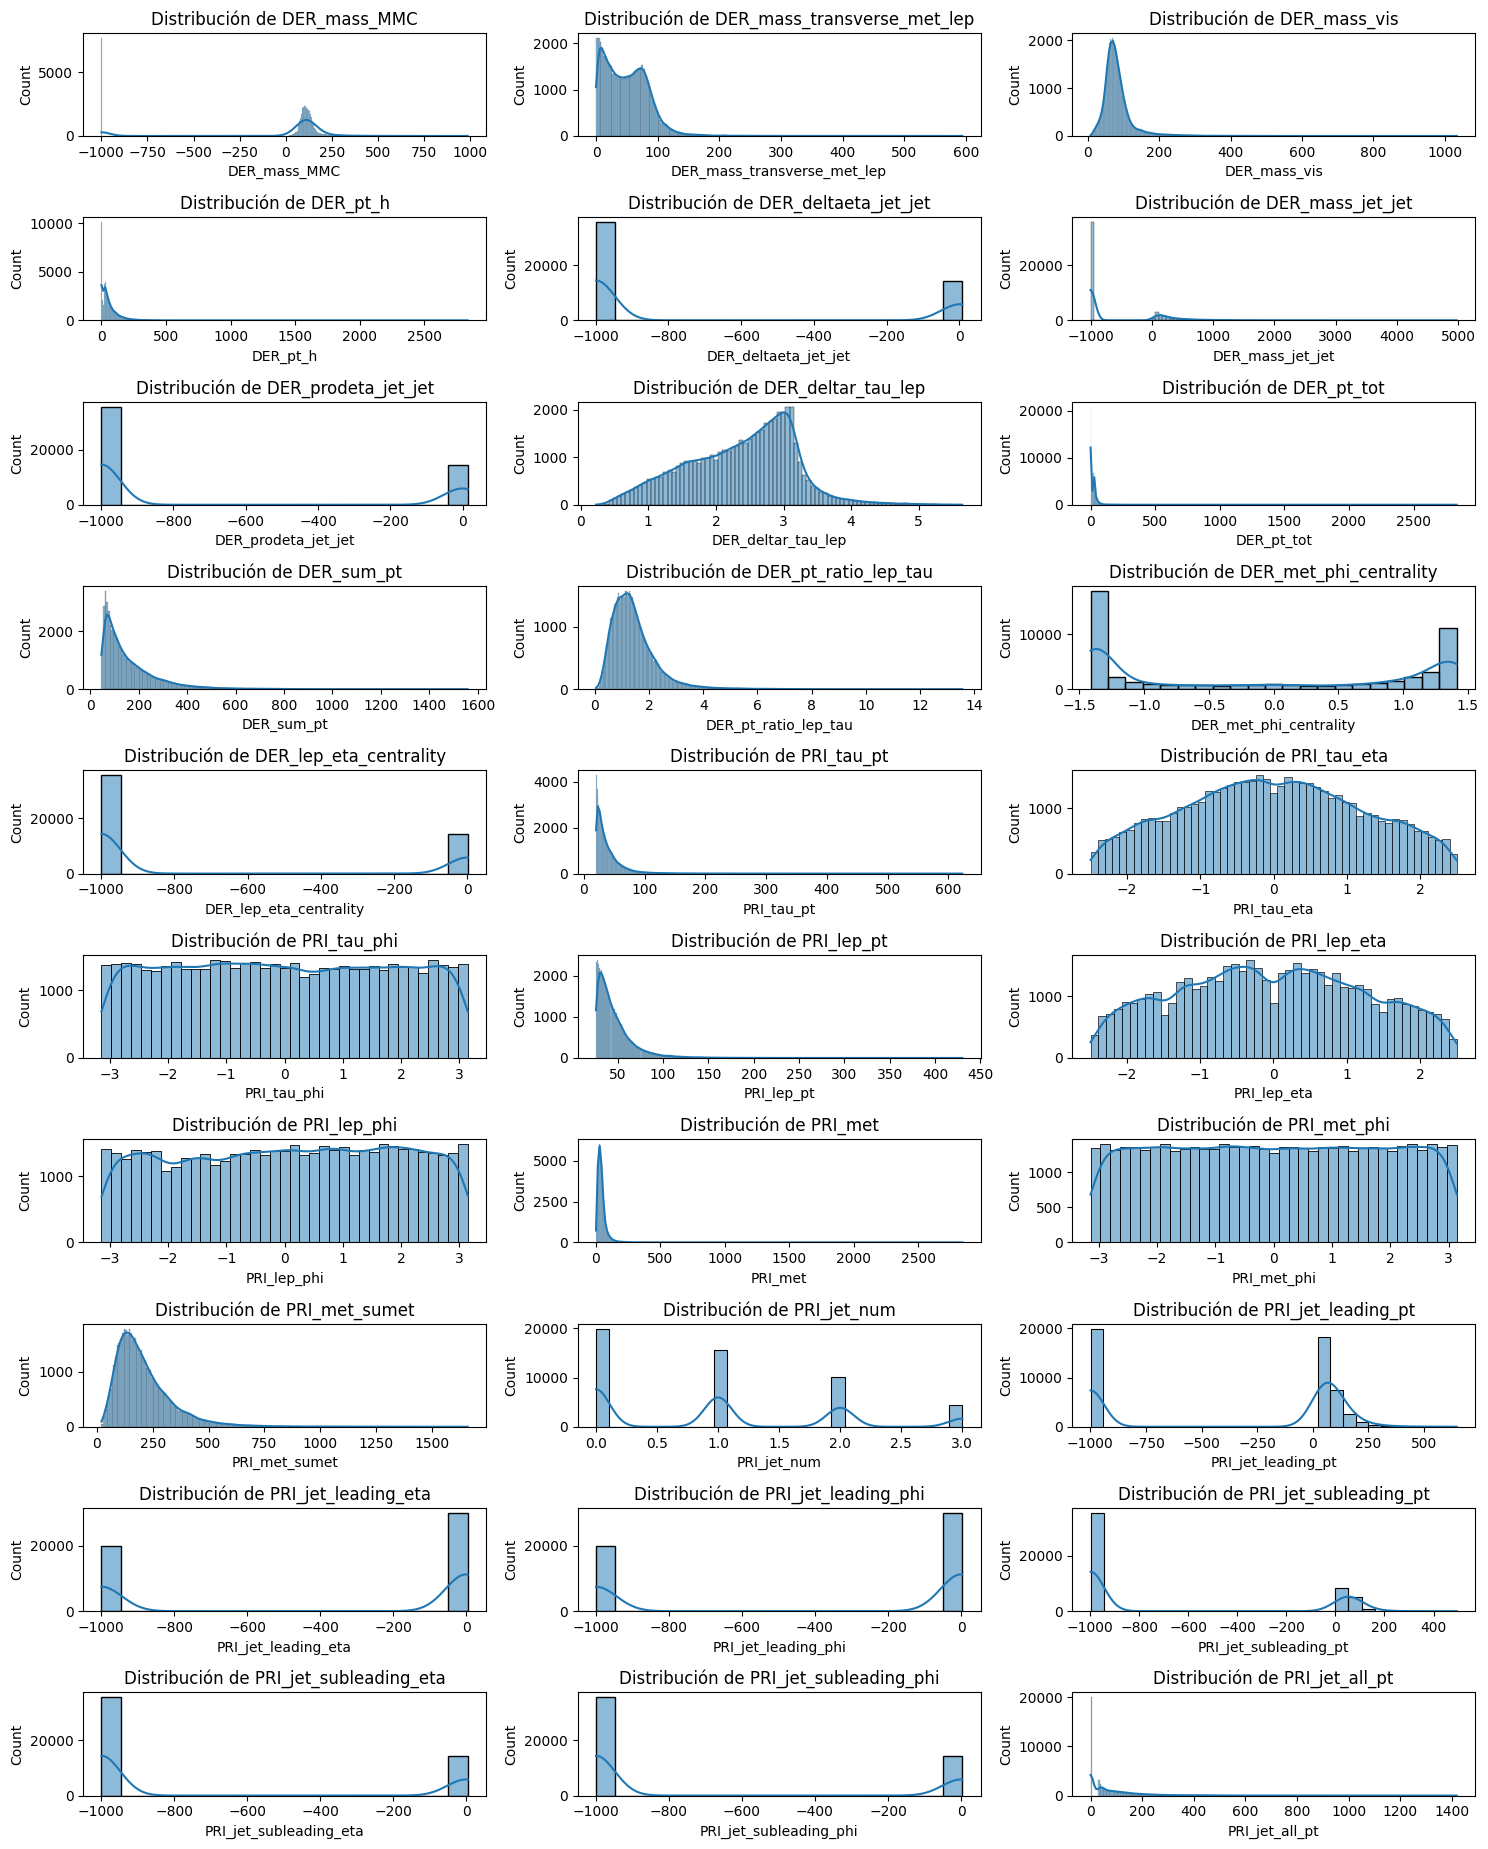

In [40]:
#Graficamos cada feature como histograma (Toda feature es numerica)

#Utilizamos una parte de todo X_train por cuestiones de rendimiento
#50000 es un buen candidato por la Ley de los grandes nros. + Teo. Central Limite
X_sample = X_train.sample(n=50000, random_state=rand_state)

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos una rejilla de gráficos
plt.figure(figsize=(15, 20))
for i, col in enumerate(X_sample.columns):
    plt.subplot(len(X_sample.columns) // 3 + 1, 3, i + 1)
    sns.histplot(X_sample[col], kde=True) # kde=True dibuja la curva de la distribución
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

In [45]:
#Creamos la matriz de correlacion respecto a la feature objetivo
df_temp = X_train.copy()
df_temp['target'] = y_train
matriz_corr = df_temp.corr()

matriz_corr

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,target
DER_mass_MMC,1.000000,-0.455755,0.168548,0.198765,0.162661,0.160524,0.162521,0.228105,0.045826,0.201464,...,0.221984,0.221078,0.250158,0.247083,0.247078,0.162836,0.162614,0.162609,0.185372,0.239149
DER_mass_transverse_met_lep,-0.455755,1.000000,0.190109,-0.249116,-0.176386,-0.190392,-0.175942,0.043251,0.017758,-0.146837,...,-0.167811,-0.210537,-0.229674,-0.220370,-0.220355,-0.176837,-0.176231,-0.176225,-0.210009,-0.351428
DER_mass_vis,0.168548,0.190109,1.000000,-0.062562,-0.032251,-0.040620,-0.032126,0.579712,-0.000702,0.088685,...,0.053300,-0.026860,-0.019151,-0.013749,-0.013742,-0.033188,-0.032202,-0.032206,-0.052902,-0.014055
DER_pt_h,0.198765,-0.249116,-0.062562,1.000000,0.523664,0.534531,0.523639,-0.539379,0.310501,0.832733,...,0.782547,0.623401,0.621599,0.564898,0.564894,0.531647,0.523714,0.523703,0.808616,0.192526
DER_deltaeta_jet_jet,0.162661,-0.176386,-0.032251,0.523664,1.000000,0.946045,0.999981,-0.299076,0.270878,0.671996,...,0.619100,0.867521,0.545027,0.521657,0.521664,0.999346,0.999995,0.999996,0.712446,0.141646
DER_mass_jet_jet,0.160524,-0.190392,-0.040620,0.534531,0.946045,1.000000,0.944443,-0.303751,0.247771,0.680700,...,0.617057,0.814191,0.521645,0.493233,0.493241,0.947652,0.945505,0.945507,0.719962,0.191766
DER_prodeta_jet_jet,0.162521,-0.175942,-0.032126,0.523639,0.999981,0.944443,1.000000,-0.299083,0.271435,0.672158,...,0.619388,0.867741,0.545022,0.521653,0.521661,0.999347,0.999988,0.999989,0.712620,0.140554
DER_deltar_tau_lep,0.228105,0.043251,0.579712,-0.539379,-0.299076,-0.303751,-0.299083,1.000000,-0.148081,-0.432603,...,-0.407002,-0.347904,-0.335851,-0.304161,-0.304145,-0.303416,-0.299107,-0.299101,-0.448737,0.012245
DER_pt_tot,0.045826,0.017758,-0.000702,0.310501,0.270878,0.247771,0.271435,-0.148081,1.000000,0.381160,...,0.448925,0.360409,0.202920,0.186564,0.186590,0.279203,0.271100,0.271091,0.403382,-0.015287
DER_sum_pt,0.201464,-0.146837,0.088685,0.832733,0.671996,0.680700,0.672158,-0.432603,0.381160,1.000000,...,0.904481,0.758503,0.638796,0.578616,0.578621,0.687465,0.672125,0.672114,0.965628,0.153236


In [ ]:
from sklearn.feature_selection import mutual_info_classif

#Correlacion entre el target y cada feature
feature_importance = mutual_info_classif(X_train, y_train, random_state=rand_state)

obj_feature_importance = pd.Series(feature_importance, index=X_train.columns)
print(obj_feature_importance.sort_values(ascending=False))


#Una vez analizada la matriz de correlacion y la escala de Mutual Info.
#Evaluar si imprimir graficas de correlacion para las features mas relevantes

DER_mass_MMC                   0.150147
DER_mass_transverse_met_lep    0.087145
DER_mass_vis                   0.078468
DER_deltaeta_jet_jet           0.063102
DER_prodeta_jet_jet            0.059465
DER_lep_eta_centrality         0.055663
PRI_tau_pt                     0.053512
DER_mass_jet_jet               0.048599
PRI_jet_subleading_eta         0.048014
DER_met_phi_centrality         0.046825
DER_pt_ratio_lep_tau           0.042738
PRI_jet_subleading_phi         0.041047
PRI_jet_subleading_pt          0.039969
PRI_jet_leading_eta            0.037628
PRI_jet_leading_phi            0.028671
PRI_jet_num                    0.027752
PRI_jet_leading_pt             0.026461
DER_sum_pt                     0.026239
PRI_jet_all_pt                 0.020563
DER_pt_h                       0.020492
PRI_met_sumet                  0.018701
DER_deltar_tau_lep             0.015911
PRI_met                        0.015887
PRI_lep_eta                    0.011553
PRI_tau_eta                    0.005660


In [ ]:
#Identificar posibles features mezcladas
#Identificar transformaciones para las features, como reescalarlas, estandarizarlas
#o centrar su distribucion con log(.) o sqrt(.)
 